In [4]:
import pandas as pd
import numpy as np
import sqlite3
import json
import torch
from scipy.stats import norm
from scipy.optimize import brentq
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import matplotlib.dates as mdates
import math
import os
import statsmodels.api as sm
from scipy import stats
from scipy.stats.mstats import winsorize
from statsmodels.stats.sandwich_covariance import cov_hac
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)  # 显示所有列
pd.set_option('display.max_rows', 100)     # 显示前100行

os.chdir('/Users/jianbinchen/NonSync/GitHub/Research/PricingTailRisk_MDN/code')

In [5]:
!pwd

/Users/jianbinchen/NonSync/GitHub/Research/PricingTailRisk_MDN/code


In [6]:

final_oos_df = pd.read_parquet('/Users/jianbinchen/Downloads/final_oos_df_20260511_0502.parquet')
metrics_df=pd.read_parquet('/Users/jianbinchen/Downloads/metrics_df_20260511_0502.parquet')
ES_df = pd.read_parquet('/Users/jianbinchen/Downloads/ES_df_20260511_0502.parquet') 

# micro_df = pd.read_parquet('/kaggle/input/datasets/jianbinchenuc/mdndata-1990/micro_data.parquet') 
micro_df = pd.read_parquet('/Users/jianbinchen/NonSync/GitHub/Research/PricingTailRisk_MDN/data/micro_data.parquet')

ES_df.head(5)

,permno,date,es_1,var_1,es_5,var_5,es_10,var_10,pit,crps,mean_pred,vol_pred,realized_ret
0,10001,2006-01-31,0.375756,-0.251241,0.205456,-0.121250,0.151356,-0.078381,0.306799,0.034053,0.051918,0.148757,-0.010537
1,10001,2006-02-28,0.378124,-0.230293,0.207311,-0.128125,0.155972,-0.086320,0.935980,0.120855,0.018342,0.119724,0.170394
2,10001,2006-03-31,0.452418,-0.316461,0.273345,-0.179523,0.212601,-0.131149,0.178688,0.054298,0.002425,0.148913,-0.094632
3,10001,2006-04-30,0.348968,-0.242963,0.202683,-0.126761,0.154445,-0.090460,0.405021,0.021911,0.013817,0.110207,-0.010372
4,10001,2006-05-31,0.330319,-0.213291,0.189141,-0.121051,0.145622,-0.087730,0.129000,0.047398,0.002000,0.101715,-0.076388


In [7]:
metrics_df.head(5)

,window,train_period,test_period,duration_sec,best_val_loss,epochs_run,train_loss_trace,val_loss_trace
0,1,1990-01 to 2004-12,2006-01 to 2006-12,1041.293834,-0.706860,52,"[-0.12757864431432442, -0.4008487801367085, -0...","[-0.6709895558226827, -0.6987624529534938, -0...."
1,2,1990-01 to 2005-12,2007-01 to 2007-12,573.148829,-0.809060,25,"[-0.5422132595692462, -0.5429368317183474, -0....","[-0.7996487150799175, -0.7989326711420421, -0...."
2,3,1990-01 to 2006-12,2008-01 to 2008-12,621.848662,-0.634309,26,"[-0.5946373150084805, -0.5959043949748581, -0....","[-0.6338824714110587, -0.6232412235340561, -0...."
3,4,1990-01 to 2007-12,2009-01 to 2009-12,543.135703,0.107664,21,"[-0.6195080646521616, -0.6227381542004392, -0....","[0.10766363483189821, 0.11526605093695061, 0.1..."
4,5,1990-01 to 2008-12,2010-01 to 2010-12,2486.658858,-0.408882,106,"[-0.5564266515568148, -0.5646324909962663, -0....","[-0.3883233175236492, -0.3877370060184211, -0...."


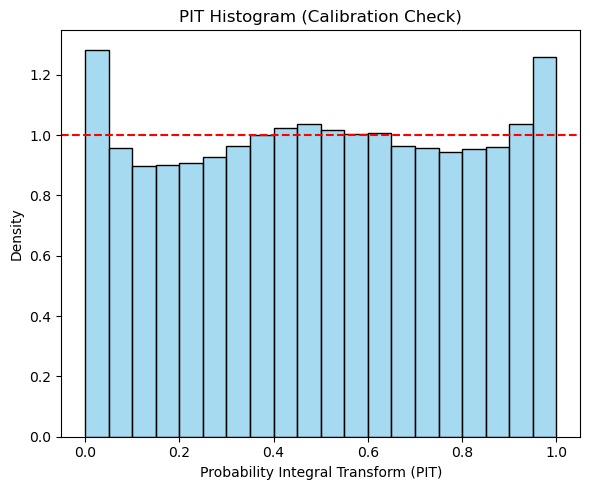

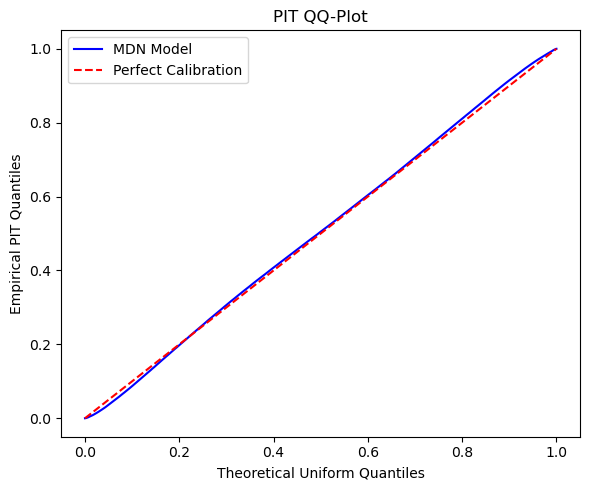

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# =================================================================
# 3. 分布校准检验 (PIT Test) - 拆分为独立图表
# =================================================================

# -------------------------
# 图 A: PIT 直方图
# -------------------------
plt.figure(figsize=(6, 5)) # 调整为单图的经典长宽比
# 加上 edgecolor='black' 让柱子边缘更清晰，符合学术审美
sns.histplot(ES_df['pit'], bins=20, kde=False, stat="density", color='skyblue', edgecolor='black')
plt.axhline(y=1, color='red', linestyle='--') 
plt.title("PIT Histogram (Calibration Check)")
plt.xlabel("Probability Integral Transform (PIT)")
plt.ylabel("Density")

plt.tight_layout()
# 导出为无损 PDF，bbox_inches='tight' 切除多余白边
plt.savefig('../paper/fig/pit_histogram.pdf', format='pdf', bbox_inches='tight')
plt.show()
plt.close() # 关闭画布，避免内存泄漏和图表重叠
# print("✅ PIT Histogram 已保存为 ../paper/fig/pit_histogram.pdf")


# -------------------------
# 图 B: PIT QQ-Plot
# -------------------------
plt.figure(figsize=(6, 5))
sorted_pit = np.sort(ES_df['pit'])
uniform_dist = np.linspace(0, 1, len(sorted_pit))

plt.plot(uniform_dist, sorted_pit, color='blue', label='MDN Model')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Perfect Calibration')

plt.title("PIT QQ-Plot")
plt.xlabel("Theoretical Uniform Quantiles")
plt.ylabel("Empirical PIT Quantiles")
plt.legend()

plt.tight_layout()
plt.savefig('../paper/fig/pit_qq_plot.pdf', format='pdf', bbox_inches='tight')
plt.show()
plt.close()
# print("✅ PIT QQ-Plot 已保存为 ../paper/fig/pit_qq_plot.pdf")


>>> Calculating Traditional Benchmark CRPS (with Global Warm-up) <<<

>>> CRPS Diagnostic Summary <<<
Benchmark (12m Historical Normal) Mean CRPS : 0.0906
MDN (Dynamic Mixture Network) Mean CRPS     : 0.0875
⭐ MDN Skill Score (Error Reduction)          : 3.48%


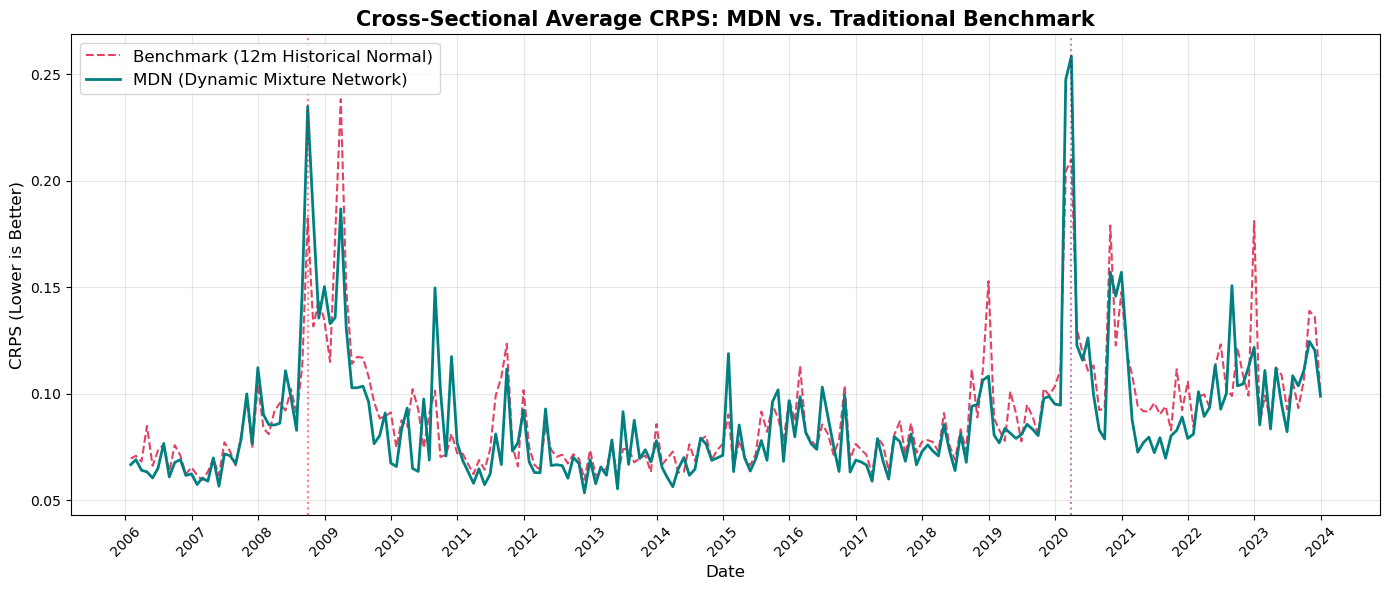

In [9]:
# =================================================================
# 5. CRPS 深度诊断与可视化 (引入传统历史基准线) - 修复冷启动版
# =================================================================

print("\n>>> Calculating Traditional Benchmark CRPS (with Global Warm-up) <<<")

# -----------------------------------------------------------------
# 🌟 修复: 全局计算 Benchmark (防止测试集初期的冷启动缺失)
# -----------------------------------------------------------------
# 1. 重新读取包含所有历史年份 (1990-2023) 的收益率数据。

bench_df = micro_df[['permno', 'mthcaldt', 'mthret']].copy()

# 统一列名并排序
bench_df['mthcaldt'] = pd.to_datetime(bench_df['mthcaldt']) + pd.offsets.MonthEnd(0)
bench_df = bench_df.rename(columns={'mthcaldt': 'date'})
# 🌟 终极修复：排序后必须重置索引！斩断底层多线程读取带来的哈希错乱！
bench_df = bench_df.sort_values(['permno', 'date']).reset_index(drop=True)

# 3. 在完整的全局时间序列上，计算 12 个月滚动均值和标准差
bench_df['mu_bench'] = bench_df.groupby('permno')['mthret'].transform(lambda x: x.rolling(12, min_periods=3).mean())
bench_df['sigma_bench'] = bench_df.groupby('permno')['mthret'].transform(lambda x: x.rolling(12, min_periods=3).std())

# 4. 把全局算好的精准 Benchmark 基准，贴回到你的样本外预测表 ES_df 中
ES_df = pd.merge(
    ES_df, 
    bench_df[['permno', 'date', 'mu_bench', 'sigma_bench']], 
    on=['permno', 'date'], 
    how='left'
)

# 5. 兜底逻辑：只为真正刚上市、连 3 个月历史都没有的新股进行截面填充
ES_df['mu_bench'] = ES_df['mu_bench'].fillna(ES_df.groupby('date')['mu_bench'].transform('mean')).fillna(0)
ES_df['sigma_bench'] = ES_df['sigma_bench'].fillna(ES_df.groupby('date')['sigma_bench'].transform('mean')).fillna(0.1)

# 防止波动率出现 0 导致除以零崩溃
ES_df['sigma_bench'] = np.maximum(ES_df['sigma_bench'], 1e-6)

# -----------------------------------------------------------------

# 2. 使用单一正态分布的 CRPS 解析解公式极速计算
def crps_normal_analytical(y, mu, sigma):
    """单正态分布 CRPS 的封闭解析解 (Gneiting et al., 2005)"""
    z = (y - mu) / sigma
    return sigma * (z * (2 * norm.cdf(z) - 1) + 2 * norm.pdf(z) - 1 / np.sqrt(np.pi))

ES_df['crps_bench'] = crps_normal_analytical(
    ES_df['realized_ret'].values, 
    ES_df['mu_bench'].values, 
    ES_df['sigma_bench'].values
)

# 3. 打印统计输出 (Skill Score)
mean_crps_mdn = ES_df['crps'].mean()
mean_crps_bench = ES_df['crps_bench'].mean()
skill_score = (1 - mean_crps_mdn / mean_crps_bench) * 100

print("\n>>> CRPS Diagnostic Summary <<<")
print(f"Benchmark (12m Historical Normal) Mean CRPS : {mean_crps_bench:.4f}")
print(f"MDN (Dynamic Mixture Network) Mean CRPS     : {mean_crps_mdn:.4f}")
print(f"⭐ MDN Skill Score (Error Reduction)          : {skill_score:.2f}%")

# 4. 绘制对比走势图
monthly_crps = ES_df.groupby('date')[['crps', 'crps_bench']].mean().reset_index()
monthly_crps['date'] = pd.to_datetime(monthly_crps['date'])

plt.figure(figsize=(14, 6))

# 画 Benchmark 基准线
plt.plot(monthly_crps['date'], monthly_crps['crps_bench'], color='crimson', linewidth=1.5, linestyle='--', alpha=0.8, label='Benchmark (12m Historical Normal)')

# 画 MDN 模型线
plt.plot(monthly_crps['date'], monthly_crps['crps'], color='teal', linewidth=2, label='MDN (Dynamic Mixture Network)')

plt.title("Cross-Sectional Average CRPS: MDN vs. Traditional Benchmark", fontsize=15, fontweight='bold')
plt.ylabel("CRPS (Lower is Better)", fontsize=12)
plt.xlabel("Date", fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12, loc='upper left')

plt.axvline(pd.to_datetime('2008-09-30'), color='red', alpha=0.5, linestyle=':', label='Lehman Bankruptcy')
if pd.to_datetime('2020-03-31') <= monthly_crps['date'].max():
    plt.axvline(pd.to_datetime('2020-03-31'), color='purple', alpha=0.5, linestyle=':', label='COVID-19 Crash')

plt.xticks(rotation=45)
plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.savefig('../paper/fig/crps_comparison.pdf', format='pdf', bbox_inches='tight')
plt.show()

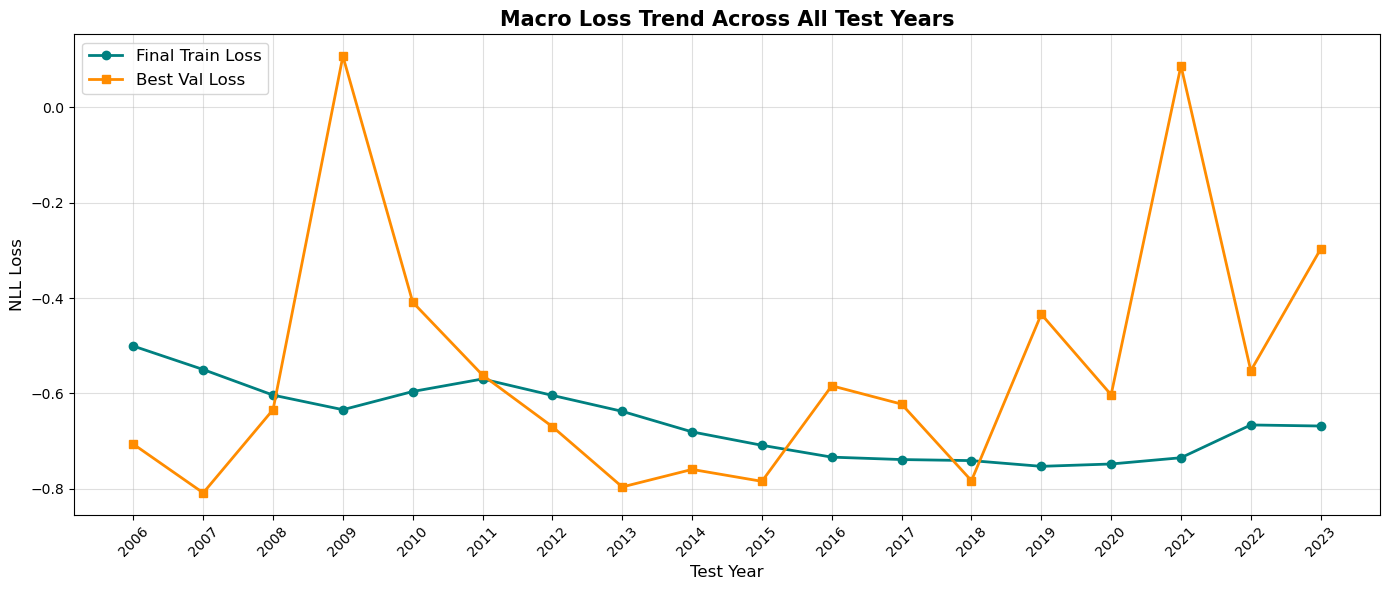

In [10]:
def plot_macro_loss_trend(df):
    plt.figure(figsize=(14, 6))
    
    # 提取每个窗口的最终 Train Loss
    final_train_loss = [trace[-1] for trace in df['train_loss_trace']]
    # 提取验证集最佳 Loss
    best_val_loss = df['best_val_loss'].tolist()
    
    # 提取年份作为 X 轴标签 (假设 test_period 格式为 "2006-01 to 2006-12")
    years = [period.split('-')[0] for period in df['test_period']]
    
    plt.plot(df['window'], final_train_loss, label='Final Train Loss', marker='o', color='teal', linewidth=2)
    plt.plot(df['window'], best_val_loss, label='Best Val Loss', marker='s', color='darkorange', linewidth=2)
    
    plt.xticks(df['window'], years, rotation=45)
    plt.title("Macro Loss Trend Across All Test Years", fontsize=15, fontweight='bold')
    plt.xlabel("Test Year", fontsize=12)
    plt.ylabel("NLL Loss", fontsize=12)
    plt.legend(fontsize=12)
    plt.grid(True, alpha=0.4)
    plt.tight_layout()
    plt.show()

# 运行趋势图
plot_macro_loss_trend(metrics_df)

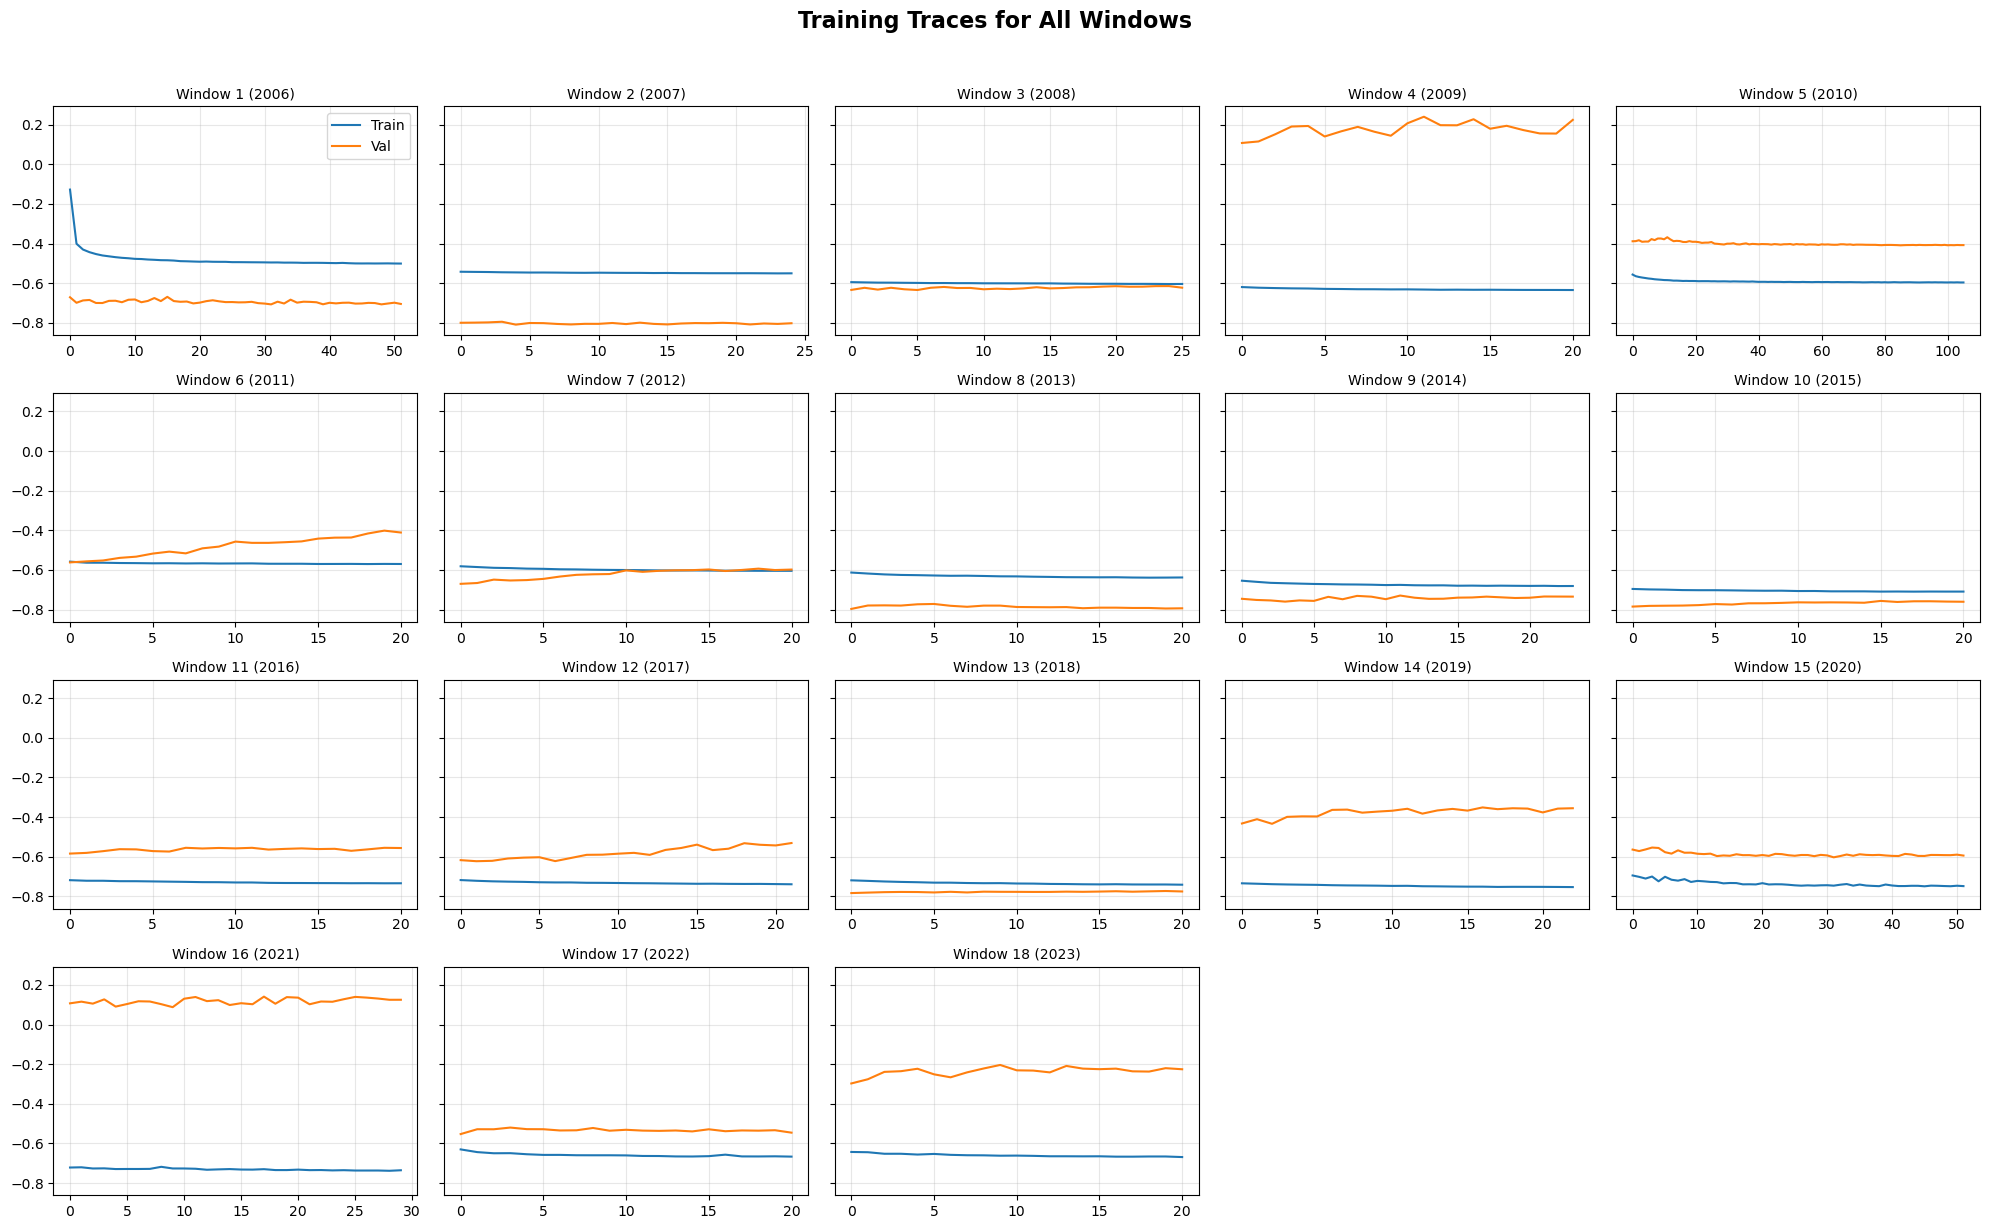

In [11]:
def plot_all_traces_grid(df):
    n_windows = len(df)
    cols = 5  # 每排画 5 个窗口
    rows = math.ceil(n_windows / cols)
    
    # 创建一个巨大的画布
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 3 * rows), sharex=False, sharey=True)
    axes = axes.flatten()
    
    for idx, row in df.iterrows():
        ax = axes[idx]
        year = row['test_period'].split('-')[0]
        
        ax.plot(row['train_loss_trace'], label='Train')
        ax.plot(row['val_loss_trace'], label='Val')
        ax.set_title(f"Window {row['window']} ({year})", fontsize=10)
        ax.grid(True, alpha=0.3)
        
        # 只在第一个图显示图例，保持画面整洁
        if idx == 0:
            ax.legend()
            
    # 隐藏多余的空白子图
    for i in range(n_windows, len(axes)):
        axes[i].set_visible(False)
        
    plt.suptitle("Training Traces for All Windows", fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

# 运行展板图
plot_all_traces_grid(metrics_df)

正在分析数据，时间范围: 2006-01-31 到 2023-12-31


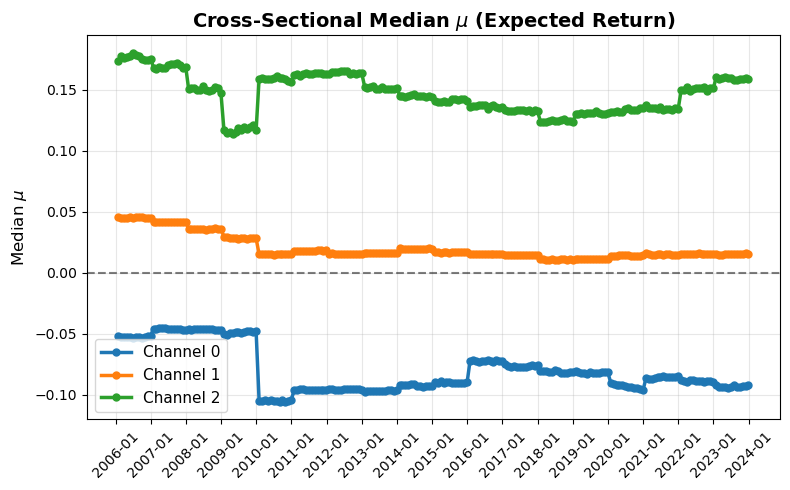

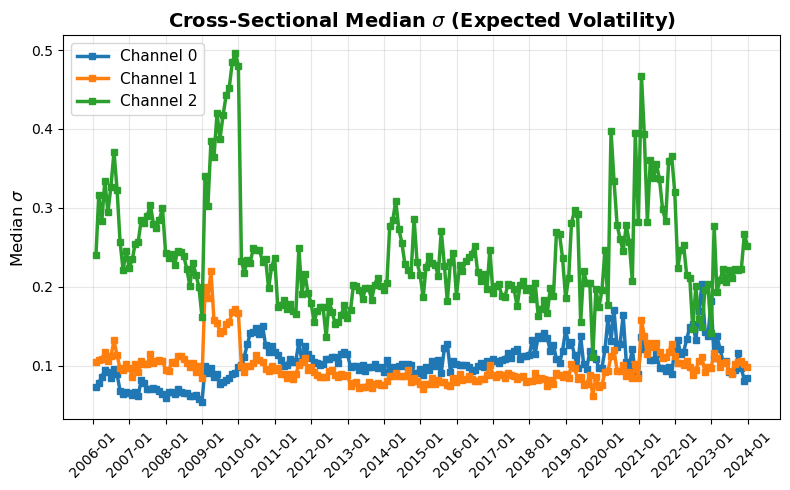

In [12]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

def plot_regime_dynamics(df_preds, target_year=None, time_col='mthcaldt'):
    """
    通用函数：绘制指定年份（或全样本）内，每个通道的 mu 和 sigma 演化轨迹
    (已修改为输出两张独立的 PDF 图片以供 LaTeX 排版)
    """
    # 确保图片保存的文件夹存在
    if not os.path.exists('fig'):
        os.makedirs('fig')
        
    df = df_preds.copy()
    df[time_col] = pd.to_datetime(df[time_col])
    
    # 确定文件后缀名
    year_suffix = str(target_year) if target_year is not None else "all"
    
    # 如果指定了年份，则过滤数据
    if target_year is not None:
        df = df[df[time_col].dt.year == target_year]
        if df.empty:
            print(f"警告：未找到 {target_year} 年的数据！")
            return
            
    print(f"正在分析数据，时间范围: {df[time_col].min().date()} 到 {df[time_col].max().date()}")

    # 1. 安全解析 JSON 字符串到 numpy 数组
    if isinstance(df['mu_vec'].iloc[0], str):
        df['mu_arr'] = df['mu_vec'].apply(lambda x: np.array(json.loads(x)))
        df['sigma_arr'] = df['sigma_vec'].apply(lambda x: np.array(json.loads(x)))
    else:
        df['mu_arr'] = df['mu_vec'].apply(np.array)
        df['sigma_arr'] = df['sigma_vec'].apply(np.array)

    num_components = len(df['mu_arr'].iloc[0])
    
    # 2. 定义逐月计算中位数的聚合函数
    def get_monthly_medians(month_df):
        mu_mat = np.vstack(month_df['mu_arr'].values)
        sigma_mat = np.vstack(month_df['sigma_arr'].values)
        
        mu_medians = np.median(mu_mat, axis=0)
        sigma_medians = np.median(sigma_mat, axis=0)
        
        res = {}
        for k in range(num_components):
            res[f'ch{k}_mu'] = mu_medians[k]
            res[f'ch{k}_sigma'] = sigma_medians[k]
        return pd.Series(res)

    # 3. 按月分组并计算
    monthly_stats = df.groupby(time_col).apply(get_monthly_medians).reset_index()
    colors = plt.cm.tab10.colors  

    # ==========================================
    # 图 A：预期收益率 (Mu) 演化
    # ==========================================
    plt.figure(figsize=(8, 5))
    for k in range(num_components):
        plt.plot(monthly_stats[time_col], monthly_stats[f'ch{k}_mu'], 
                 label=f'Channel {k}', color=colors[k], linewidth=2.5, marker='o', markersize=5)
    
    plt.axhline(0, color='black', linestyle='--', alpha=0.5) 
    plt.title(f"Cross-Sectional Median $\mu$ (Expected Return)", fontsize=14, fontweight='bold')
    plt.ylabel("Median $\mu$", fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=11)

    # 优化时间轴
    ax = plt.gca()
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    if target_year is None:
        ax.xaxis.set_major_locator(mdates.YearLocator(1))
    else:
        ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    plt.xticks(rotation=45)

    plt.tight_layout()
    mu_filename = f'../paper/fig/regime_mu_{year_suffix}.pdf'
    plt.savefig(mu_filename, format='pdf', bbox_inches='tight')
    plt.show()
    plt.close()
    # print(f"✅ Mu 演化图已保存为: {mu_filename}")

    # ==========================================
    # 图 B：预期波动率 (Sigma) 演化
    # ==========================================
    plt.figure(figsize=(8, 5))
    for k in range(num_components):
        plt.plot(monthly_stats[time_col], monthly_stats[f'ch{k}_sigma'], 
                 label=f'Channel {k}', color=colors[k], linewidth=2.5, marker='s', markersize=5)
    
    plt.title(f"Cross-Sectional Median $\sigma$ (Expected Volatility)", fontsize=14, fontweight='bold')
    plt.ylabel("Median $\sigma$", fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=11)

    # 优化时间轴
    ax = plt.gca()
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    if target_year is None:
        ax.xaxis.set_major_locator(mdates.YearLocator(1))
    else:
        ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    plt.xticks(rotation=45)

    plt.tight_layout()
    sigma_filename = f'../paper/fig/regime_sigma_{year_suffix}.pdf'
    plt.savefig(sigma_filename, format='pdf', bbox_inches='tight')
    plt.show()
    plt.close()
    # print(f"✅ Sigma 演化图已保存为: {sigma_filename}")

# 运行示例：
plot_regime_dynamics(final_oos_df)

In [13]:
# =================================================================
# Phase 4: 资产定价终极测试 (Asset Pricing Tests)
# 1. 10分位组合排序 (Decile Sorts)
# 2. Fama-MacBeth 截面回归 (Cross-Sectional Regression)
# 3. 投资组合 Alpha 测试 (Time-Series Factor Spanning Test)
# =================================================================

# 1. 对齐日期列进行合并
# ES_df 的日期叫 'date', micro_df 的日期叫 'mthcaldt'
df_micro_subset = micro_df[['permno', 'mthcaldt', 'mthprc', 'mthcap', 'mthcap_log', 'bm', 'MOM12m', 'mthret_lead1']]
df = pd.merge(ES_df, df_micro_subset, 
              left_on=['permno', 'date'], 
              right_on=['permno', 'mthcaldt'], 
              how='inner')

# 2. 清理缺失值：确保用于排序、加权和回归的核心列没有 NaN
cols_to_dropna = ['es_5', 'mthret_lead1', 'mthcap', 'mthprc', 'mthcap_log', 'bm', 'MOM12m']
df = df.dropna(subset=cols_to_dropna).copy()

# 3. 仙股过滤 (Penny Stock Filter)：剔除建仓当月价格低于 5 美元的股票
# CRSP 数据库中负价格代表买卖中间价，必须取绝对值
# df['price_abs'] = np.abs(df['mthprc'])
initial_len = len(df)
df = df[df['mthprc'] >= 5.0]
print(f"    -> Filtered {initial_len - len(df)} penny stock observations (< $5).")

# =================================================================
# 第二步：市值加权 10 分位测试 (Value-Weighted Decile Sorts)
# =================================================================
print("\n>>> 2. Running Value-Weighted Portfolio Sorts...")

# 1. 按月对预期尾部风险 (es_5) 进行 10 等分
def get_deciles(x):
    # return pd.qcut(x, 10, labels=False, duplicates='drop') + 1
    # 在 pd.qcut 的默认设置下，第 10 组的 es_5 最大，第 1 组的 es_5 最小。
    return pd.qcut(x, 10, labels=False) + 1

df['decile'] = df.groupby('date')['es_5'].transform(get_deciles)

# 2. 计算市值加权收益率 (VW Returns)
def vw_return(group):
    if group['mthcap'].sum() == 0: 
        return np.nan
    # 使用 t 时刻的市值 (mthcap) 作为权重，加权 t+1 期的真实收益率 (mthret_lead1)
    return np.average(group['mthret_lead1'], weights=group['mthcap'])

# 计算各组每月的加权收益率
vw_ret = df.groupby(['date', 'decile']).apply(vw_return).unstack()

# 构建多空组合 (Long-Short Portfolio)：做多风险最高组(10)，做空风险最低组(1)
# 这里 10 代表尾部风险最大
vw_ret['High-Low'] = vw_ret[10] - vw_ret[1]

# 3. 统计输出表
print("\n--- Value-Weighted Decile Portfolios (Monthly Returns %) ---")
summary_vw = pd.DataFrame(index=vw_ret.columns)
summary_vw['Mean (Ann. %)'] = vw_ret.mean() * 12 * 100
summary_vw['Vol (Ann. %)']  = vw_ret.std() * np.sqrt(12) * 100
summary_vw['Sharpe']        = summary_vw['Mean (Ann. %)'] / summary_vw['Vol (Ann. %)']
# 计算均值是否显著异于 0 的 t 统计量
def get_nw_tstat(x, lags=None):
    # 自动选择滞后阶数，常用的是 lags=int(4*(n/100)**(2/9))
    x = x.dropna()
    n = len(x)
    if lags is None: lags = int(n**(1/4)) 
    
    # 对常数项回归，获取均值及其 Newey-West 标准误
    model = sm.OLS(x, np.ones(n)).fit(cov_type='HAC', cov_kwds={'maxlags': lags})
    return model.tvalues[0]

# 应用到你的数据上
summary_vw['t-stat'] = vw_ret.apply(get_nw_tstat)

print(summary_vw.round(2))


# =================================================================
# 第三步：Fama-MacBeth 截面回归 (Fama-MacBeth Regressions)
# =================================================================
print("\n>>> 3. Running Robust Fama-MacBeth Regressions...")

# def run_cs_reg(df_t):
#     # 截面记录太少则跳过
#     if len(df_t) < 50: return None
    
#     # 🌟 极值缩尾：将 t+1 期真实收益率在上下 1% 分位数进行截断，拯救 OLS
#     df_t['ret_lead1_win'] = winsorize(df_t['mthret_lead1'], limits=[0.01, 0.01])
    
#     # 提取自变量并进行截面标准化 (Z-score)，使得不同量纲的系数具有可比性
#     X = df_t[['es_5', 'mthcap_log', 'bm', 'MOM12m']]
#     X = (X - X.mean()) / X.std()
#     X = sm.add_constant(X)
    
#     # 因变量转为 % 方便阅读
#     y = df_t['ret_lead1_win'] * 100
    
#     model = sm.OLS(y, X).fit()
#     return model.params

# # 逐月执行截面回归
# fm_coefs = df.groupby('date').apply(run_cs_reg).dropna()

# # 时序汇总：使用 Newey-West 调整 (Lag=6) 消除时间序列自相关带来的标准误低估
# results = []
# for col in fm_coefs.columns:
#     res = sm.OLS(fm_coefs[col], np.ones(len(fm_coefs))).fit(cov_type='HAC', cov_kwds={'maxlags': 6})
#     results.append({
#         'Factor': col,
#         'Coefficient': res.params[0],
#         't-stat': res.tvalues[0],
#         'p-value': res.pvalues[0]
#     })

# fm_summary = pd.DataFrame(results).set_index('Factor')

# Step 1: Cross-sectional regressions
def run_cs_reg(df_t):
    if len(df_t) < 50:
        return None
    
    df_t = df_t.copy()
    
    # winsorize (safer than scipy)
    lower = df_t['mthret_lead1'].quantile(0.01)
    upper = df_t['mthret_lead1'].quantile(0.99)
    y = df_t['mthret_lead1'].clip(lower, upper) * 100
    
    X = df_t[['es_5', 'mthcap_log', 'bm', 'MOM12m']]
    X = sm.add_constant(X)
    
    model = sm.OLS(y, X).fit()
    return model.params

fm_coefs = df.groupby('date').apply(run_cs_reg).dropna()

# Step 2: Newey-West adjusted inference
T = len(fm_coefs)
lag = int(4 * (T / 100) ** (2/9))   # 更规范的lag选择

results = []
for col in fm_coefs.columns:
    y = fm_coefs[col]
    
    res = sm.OLS(y, np.ones(len(y))).fit(
        cov_type='HAC',
        cov_kwds={'maxlags': lag}
    )
    
    results.append({
        'Factor': col,
        'Coefficient': res.params[0],
        't-stat': res.tvalues[0],
        'p-value': res.pvalues[0]
    })

fm_summary = pd.DataFrame(results).set_index('Factor')


print("\n--- Fama-MacBeth Regression Results ---")
print("Dep. Variable: Next Month Return (%) [Winsorized]")
print("Newey-West HAC Adjusted t-statistics (Lag=6)")
print("-" * 50)
print(fm_summary.round(3))
print("-" * 50)


    -> Filtered 145286 penny stock observations (< $5).

>>> 2. Running Value-Weighted Portfolio Sorts...

--- Value-Weighted Decile Portfolios (Monthly Returns %) ---
          Mean (Ann. %)  Vol (Ann. %)  Sharpe  t-stat
decile                                               
1                 11.84         12.92    0.92    4.27
2                 10.56         16.67    0.63    2.84
3                 12.26         18.55    0.66    2.81
4                 11.68         20.69    0.56    2.29
5                 12.35         23.45    0.53    2.10
6                  8.19         23.92    0.34    1.48
7                 15.16         25.23    0.60    2.49
8                  8.16         25.33    0.32    1.31
9                  9.89         29.05    0.34    1.38
10                 6.33         34.09    0.19    0.77
High-Low          -5.51         27.82   -0.20   -0.81

>>> 3. Running Robust Fama-MacBeth Regressions...

--- Fama-MacBeth Regression Results ---
Dep. Variable: Next Month Return (%) [

In [14]:

print("=== Starting Phase 4: Institutional Asset Pricing Tests ===")
WRDS_db_path = '/Users/jianbinchen/NonSync/GitHub/Research/DataSet/WRDS.sqlite'

# =================================================================
# 第一步：数据对齐与严格清洗 (Data Merging & Cleaning)
# =================================================================
print("\n>>> 1. Merging Data and Applying Universe Filters...")

with sqlite3.connect(WRDS_db_path) as conn:
    ff_factors_monthly = pd.read_sql_query("SELECT * FROM ff_factors_monthly", conn)
    ff_fivefactors_monthly = pd.read_sql_query("SELECT * FROM ff_fivefactors_monthly", conn)

def run_institutional_asset_pricing_tests(ff_df,ff_factors):
    ff_df['date'] = pd.to_datetime(ff_df['date'])+pd.offsets.MonthEnd(0)

    # =================================================================
    # 第四步：投资组合 Alpha 测试 (Time-Series Factor Spanning Test)
    # =================================================================
    print("\n>>> 4. Running Portfolio Alpha Test (Fama-French 5-Factor)...")

    # 提取我们的 High-Low 零成本多空投资组合的时间序列收益率
    port_ret = vw_ret[['High-Low']].dropna().reset_index()
    port_ret.columns = ['date', 'High_Low_Ret']

    # 对齐日期并合并 (必须使用 inner join 确保时间严丝合缝)
    alpha_df = pd.merge(port_ret, ff_df, on='date', how='inner')

    # 构造回归模型：
    # 因为 High-Low 是做多做空的“零投资组合”，所以左侧因变量不需要再减去无风险利率 (RF)
    # y = High_Low_Ret
    # X = 'mktrf','smb','hml','umd', 'rmw','cma'

    y_alpha = alpha_df['High_Low_Ret']

    X_alpha = alpha_df[ff_factors]
    X_alpha = sm.add_constant(X_alpha) # 截距项就是我们要找的 Alpha！

    # 进行时序回归 (同样使用 Newey-West HAC 调整)
    alpha_model = sm.OLS(y_alpha, X_alpha).fit(cov_type='HAC', cov_kwds={'maxlags': 6})

    print("\n--- Fama-French 5-Factor Time-Series Regression ---")
    print(alpha_model.summary().tables[1]) # 只打印核心的系数表

    alpha_val = alpha_model.params['const']
    alpha_t = alpha_model.tvalues['const']
    print(f"\n🌟 Monthly FF5 Alpha: {alpha_val:.3f}% (t-stat: {alpha_t:.2f})")
    print(f"🌟 Annualized Alpha : {alpha_val * 12:.2f}%")


    print("\n=== Phase 4 Complete! ===")

# Fama-French 3-Factor + Momentum
run_institutional_asset_pricing_tests(ff_factors_monthly, ['mktrf','smb','hml','umd'])
# Fama-French 5-Factor + Momentum
run_institutional_asset_pricing_tests(ff_fivefactors_monthly, ['mktrf','smb','hml','umd','rmw','cma'])

=== Starting Phase 4: Institutional Asset Pricing Tests ===

>>> 1. Merging Data and Applying Universe Filters...

>>> 4. Running Portfolio Alpha Test (Fama-French 5-Factor)...

--- Fama-French 5-Factor Time-Series Regression ---
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0060      0.006     -1.072      0.284      -0.017       0.005
mktrf          0.1405      0.156      0.902      0.367      -0.165       0.446
smb           -0.1140      0.331     -0.345      0.730      -0.762       0.534
hml           -0.2531      0.233     -1.086      0.277      -0.710       0.204
umd           -0.1688      0.114     -1.476      0.140      -0.393       0.055

🌟 Monthly FF5 Alpha: -0.006% (t-stat: -1.07)
🌟 Annualized Alpha : -0.07%

=== Phase 4 Complete! ===

>>> 4. Running Portfolio Alpha Test (Fama-French 5-Factor)...

--- Fama-French 5-Factor Time-Series Regression ---


🔧 检测到模型通道数 K = 3
📊 正在按照 MEDIAN of MU 进行横截面动态重排序...


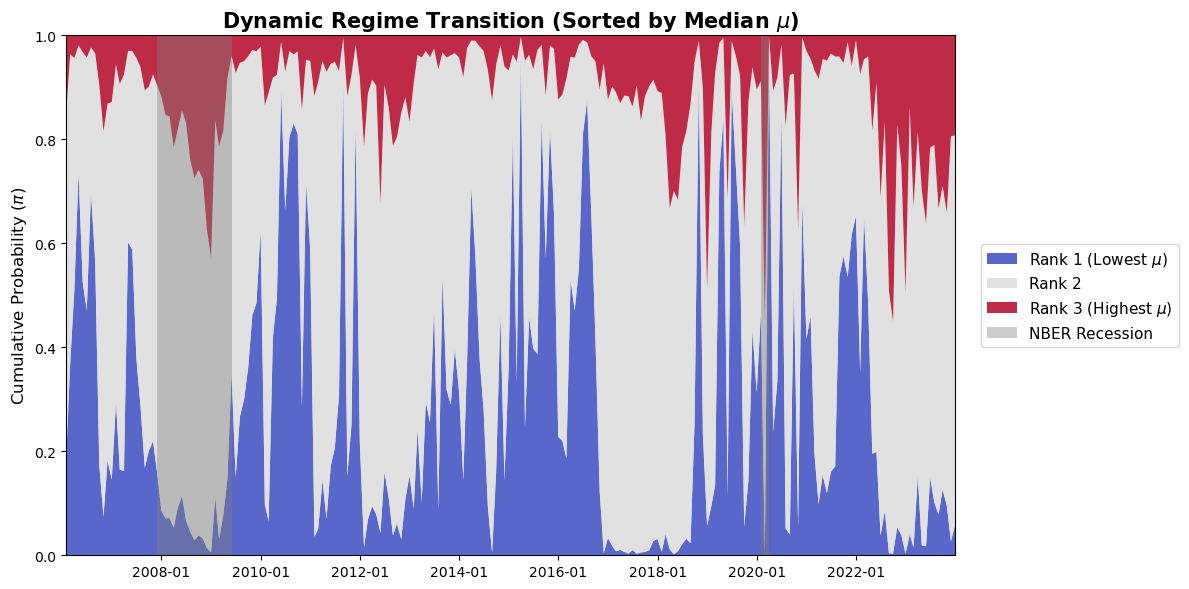

🔧 检测到模型通道数 K = 3
📊 正在按照 MEAN of SIGMA 进行横截面动态重排序...


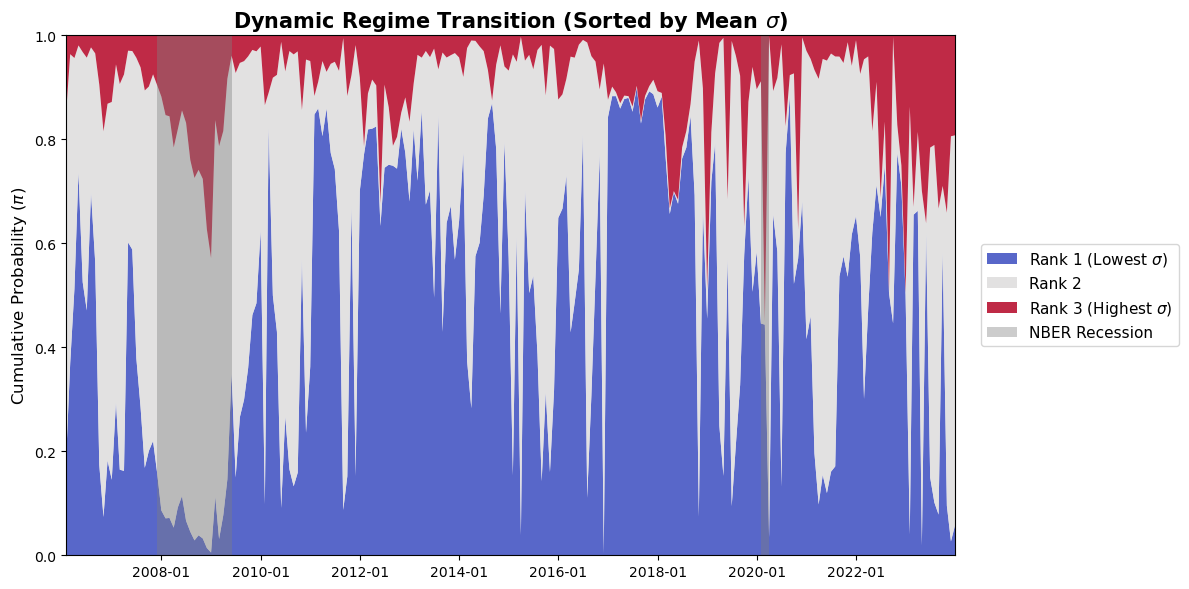

In [15]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

def plot_dynamic_sorted_pi(df_preds, time_col='mthcaldt', sort_by='mu', agg_method='median', save_path=None):
    """
    终极动态排序版：自动适应任意 K 值，并支持按 mu/sigma 和 mean/median 进行状态重排序。
    
    参数:
    - sort_by: 'mu' 或 'sigma' (决定用哪个指标来重排通道，默认 'mu')
    - agg_method: 'median' 或 'mean' (决定横截面上如何汇总数据，默认 'median')
    """
    df = df_preds.copy()
    df[time_col] = pd.to_datetime(df[time_col])
    
    # 1. 安全解析数据，并自动识别通道数 K
    for col in ['pi_vec', 'mu_vec', 'sigma_vec']:
        if isinstance(df[col].iloc[0], str):
            df[f'{col}_arr'] = df[col].apply(lambda x: np.array(json.loads(x)))
        else:
            df[f'{col}_arr'] = df[col].apply(np.array)
            
    # 动态获取 K 值
    num_components = len(df['pi_vec_arr'].iloc[0])
    print(f"🔧 检测到模型通道数 K = {num_components}")
    print(f"📊 正在按照 {agg_method.upper()} of {sort_by.upper()} 进行横截面动态重排序...")

    # 确定使用的聚合函数
    agg_func = np.median if agg_method == 'median' else np.mean

    # 2. 逐月处理：计算指标并动态排序
    def process_month(group):
        mu_mat = np.vstack(group['mu_vec_arr'].values)
        sigma_mat = np.vstack(group['sigma_vec_arr'].values)
        
        # 计算截面汇总值 (K,)
        agg_mu = agg_func(mu_mat, axis=0)
        agg_sigma = agg_func(sigma_mat, axis=0)
        
        # 决定排序的基准指标
        if sort_by == 'mu':
            sort_metric = agg_mu
        elif sort_by == 'sigma':
            sort_metric = agg_sigma
        else:
            raise ValueError("sort_by 只能是 'mu' 或 'sigma'")
            
        pi_vec = group['pi_vec_arr'].iloc[0]
        
        # 核心：从小到大排序获取索引
        sort_idx = np.argsort(sort_metric)
        
        # 根据经济学顺序，重新排列 pi 和特征
        sorted_pi = pi_vec[sort_idx]
        sorted_metric = sort_metric[sort_idx]
        
        res = {}
        for i in range(num_components):
            res[f'pi_rank_{i}'] = sorted_pi[i]
            res[f'metric_rank_{i}'] = sorted_metric[i]
        return pd.Series(res)

    # 得到按月排序后的结果
    monthly_sorted = df.groupby(time_col).apply(process_month).reset_index()
    dates = monthly_sorted[time_col].values
    pi_matrix_sorted = monthly_sorted[[f'pi_rank_{i}' for i in range(num_components)]].values

    # 3. 动态生成图例标签 (自适应任意 K)
    metric_symbol = '$\mu$' if sort_by == 'mu' else '$\sigma$'
    regime_labels = []
    for i in range(num_components):
        if i == 0:
            desc = f"Rank 1 (Lowest {metric_symbol})"
        elif i == num_components - 1:
            desc = f"Rank {i+1} (Highest {metric_symbol})"
        else:
            desc = f"Rank {i+1}"
        regime_labels.append(desc)

    # 4. 定义美国 NBER 经济衰退期
    nber_recessions = [
        ('2001-03-01', '2001-11-01'), 
        ('2007-12-01', '2009-06-01'), 
        ('2020-02-01', '2020-04-01')  
    ]
    
    # 5. 开始绘图
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # 动态渐变色：从蓝(Rank 1) 到 红(Rank K)
    colors = plt.cm.coolwarm(np.linspace(0, 1, num_components))
    
    ax.stackplot(dates, pi_matrix_sorted.T, labels=regime_labels, colors=colors, alpha=0.85)
    
    # 画 NBER 阴影
    for start, end in nber_recessions:
        start_date, end_date = pd.to_datetime(start), pd.to_datetime(end)
        if start_date <= dates[-1] and end_date >= dates[0]:
            ax.axvspan(start_date, end_date, color='grey', alpha=0.4, lw=0, 
                       label='NBER Recession' if start == '2007-12-01' else "")
            
    ax.set_title(f"Dynamic Regime Transition (Sorted by {agg_method.capitalize()} {metric_symbol})", fontsize=15, fontweight='bold')
    ax.set_ylabel("Cumulative Probability ($\pi$)", fontsize=12)
    ax.set_ylim(0, 1.0)
    ax.margins(x=0) 
    
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    plt.xticks(rotation=0)
    
    # 调整图例
    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax.legend(by_label.values(), by_label.keys(), loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=11)
    
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, format='pdf', bbox_inches='tight')
        print(f"✅ 图表已保存至 {save_path}")
        
    plt.show()

plot_dynamic_sorted_pi(final_oos_df, sort_by='mu', agg_method='median')
plot_dynamic_sorted_pi(final_oos_df, sort_by='sigma', agg_method='mean')